# Graph slicing using centrality measures



[!!! add bibliography and links to Pajek notebooks]

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import pprint as pprint

In [2]:
# https://networkx.org/documentation/stable/install.html
import networkx as nx

#### https://ipycytoscape.readthedocs.io/en/latest/installing.html
# import ipycytoscape as cy

In [3]:
import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')

In [4]:
import network_analysis_functions as naf

In [5]:
print(reload(naf))

<module 'network_analysis_functions' from '/home/francesco/kDrive/python_notebooks/sciences_historiques_numeriques/histoire_numerique_methodes/analyse_reseaux/network_analysis_functions.py'>


## NetworkX Core Number Function

The core_number function in NetworkX is used to find the core number of each node in a graph. The core number of a node is the largest k such that the node is in the k-core of the graph.
Definition of Core Number

The core number of a node is a measure of its centrality and importance in the graph. It is defined as the largest k such that the node is in the k-core of the graph. The k-core of a graph is the subgraph of nodes that have a degree of at least k.

In [6]:
# Create a simple graph
G = nx.Graph()
G.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 3),
    (3, 4),
    (4, 5),
    (5, 6)
])

naf.basic_graph_properties(G)


{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 6,
 'number_of_edges': 6,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.4}


Core numbers:  {1: 2, 2: 2, 3: 2, 4: 1, 5: 1, 6: 1}
Node colors:  [2, 2, 2, 1, 1, 1]


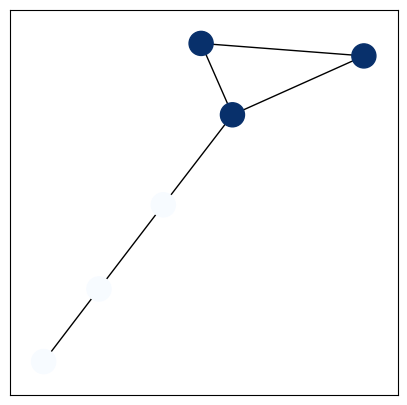

In [8]:

# Find the core number of each node
core_numbers = nx.core_number(G)
print('Core numbers: ', core_numbers)

plt.figure(figsize = (5,5))

# Visualize the graph with node colors based on core numbers
pos = nx.spring_layout(G)
colors = [core_numbers[node] for node in G.nodes()]
print('Node colors: ', colors)
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.get_cmap('Blues'))
nx.draw_networkx_edges(G, pos)
plt.show()

## Community Detection using Core Number

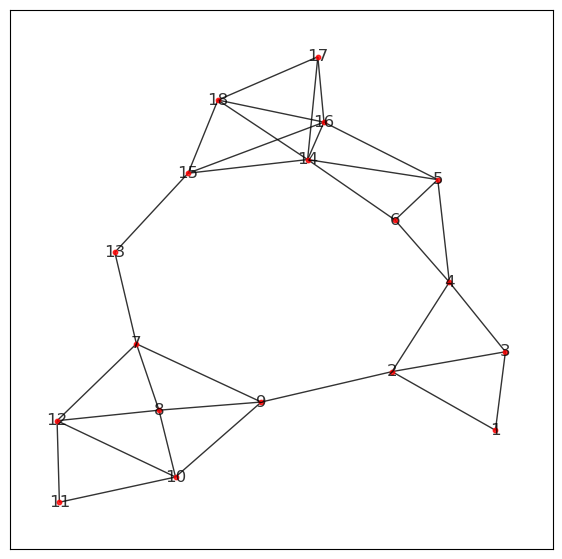

In [9]:

# Create a sample graph with three communities
G = nx.Graph()
G.add_edges_from([
    (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 5), (4, 6), (5, 6), (5,16), (5,14),  # Community 1
    (7, 8), (7, 9), (7,12), (7,13), (8, 9), (8, 10), (8,12), (9,2), (9, 10), (10, 11), (10, 12), (11, 12),  # Community 2
    (13, 15), (15,18), (14,6), (14, 15), (14, 16), (14,17),(14,18),(15, 16),  (16, 17), (16, 18), (17, 18)  # Community 3
])


plt.figure(figsize=(7,7))

pos=nx.kamada_kawai_layout(G)
#pos=nx.spring_layout(G, k=0.5)

nx.draw_networkx(G, pos=pos, node_size=10, node_color='red', alpha=0.8, with_labels=True)
plt.show()


In [10]:

# Find the core number of each node
core_numbers = nx.core_number(G)

# Print the core numbers
for node, core_number in core_numbers.items():
    print(f"Node {node}: {core_number}")

# Identify communities based on core numbers
communities = {}
for node, core_number in core_numbers.items():
    if core_number not in communities:
        communities[core_number] = [node]
    else:
        communities[core_number].append(node)

# Print the communities
cts = []
for core_number, community in communities.items():
    cts.append([core_number,community])
    print(f"Community {core_number}: {community}")


Node 1: 2
Node 2: 2
Node 3: 2
Node 4: 2
Node 5: 2
Node 6: 2
Node 16: 3
Node 14: 3
Node 7: 3
Node 8: 3
Node 9: 3
Node 12: 3
Node 13: 2
Node 10: 3
Node 11: 2
Node 15: 3
Node 18: 3
Node 17: 3
Community 2: [1, 2, 3, 4, 5, 6, 13, 11]
Community 3: [16, 14, 7, 8, 9, 12, 10, 15, 18, 17]


In [13]:
### Observe data structure of communities list
print(cts)

[[2, [1, 2, 3, 4, 5, 6, 13, 11]], [3, [16, 14, 7, 8, 9, 12, 10, 15, 18, 17]]]


In [14]:
ln = cts[1][1]
kcG = nx.subgraph(G, ln)
naf.basic_graph_properties(kcG)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 10,
 'number_of_edges': 17,
 '------': '------',
 'is connected': False,
 'components': 2,
 'density': 0.37777777777777777}


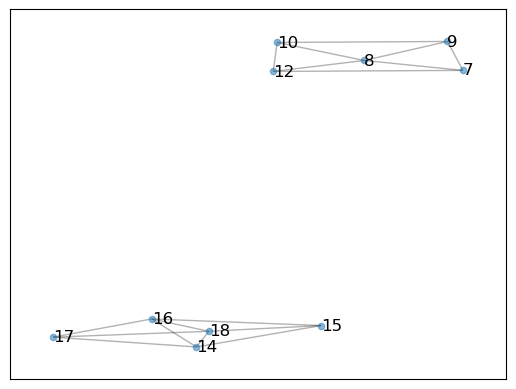

In [15]:

# Visualize the graph with communities
pos = nx.spring_layout(kcG)
nx.draw_networkx_nodes(kcG, pos, node_size=20,alpha=0.5)
nx.draw_networkx_edges(kcG, pos, alpha=0.3)
nx.draw_networkx_labels(kcG, pos, horizontalalignment='left')
plt.show()

In [16]:
### Onion layers:
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.core.onion_layers.html
pprint.pprint(nx.onion_layers(G))

{1: 1,
 2: 3,
 3: 2,
 4: 4,
 5: 6,
 6: 5,
 7: 7,
 8: 8,
 9: 7,
 10: 7,
 11: 1,
 12: 7,
 13: 1,
 14: 8,
 15: 7,
 16: 8,
 17: 7,
 18: 8}


In [17]:
# Identify communities based on onion layers
onion_layers = nx.onion_layers(G)
ol_dict = {}
for node, layer_number in onion_layers.items():
    if layer_number not in ol_dict:
        ol_dict[layer_number] = [node]
    else:
        ol_dict[layer_number].append(node)

# Print the communities
l_ol = []
for layer_number, layer_nodes in ol_dict.items():
    l_ol.append([layer_number,layer_nodes])
    print(f"Layer {layer_number}: {layer_nodes}")

Layer 1: [1, 13, 11]
Layer 2: [3]
Layer 3: [2]
Layer 4: [4]
Layer 5: [6]
Layer 6: [5]
Layer 7: [7, 9, 12, 10, 15, 17]
Layer 8: [8, 16, 14, 18]


In [18]:
ld = list(nx.degree(G))
pprint.pprint(sorted(ld, key=lambda tup: tup[1], reverse=True))


[(14, 6),
 (16, 5),
 (2, 4),
 (4, 4),
 (5, 4),
 (7, 4),
 (8, 4),
 (9, 4),
 (12, 4),
 (10, 4),
 (15, 4),
 (18, 4),
 (3, 3),
 (6, 3),
 (17, 3),
 (1, 2),
 (13, 2),
 (11, 2)]


count    18.000000
mean      3.666667
std       1.028992
min       2.000000
25%       3.000000
50%       4.000000
75%       4.000000
max       6.000000
dtype: float64


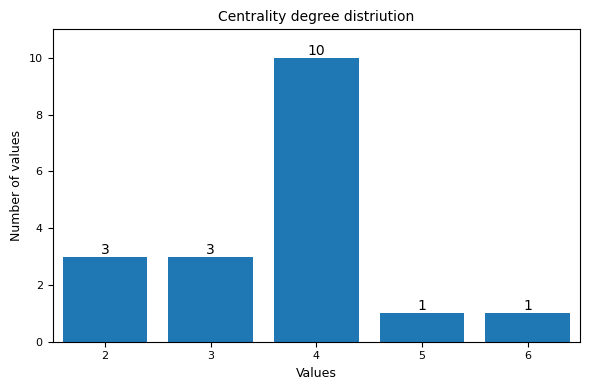

In [23]:
d = [d[1] for d in ld]
naf.describe_plot_integers_distribution(d, 6, 4, 'Centrality degree distriution')

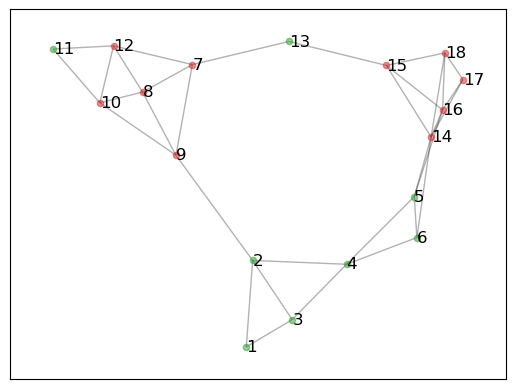

In [19]:

# Visualize the graph with communities
pos = nx.spring_layout(G)
for core_number, community in communities.items():
    nx.draw_networkx_nodes(G, pos, nodelist=community, node_color=f"C{core_number}", node_size=20,
                           alpha=0.5)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, horizontalalignment='left')
plt.show()

In [21]:
pprint.pprint(l_ol)

[[1, [1, 13, 11]],
 [2, [3]],
 [3, [2]],
 [4, [4]],
 [5, [6]],
 [6, [5]],
 [7, [7, 9, 12, 10, 15, 17]],
 [8, [8, 16, 14, 18]]]


In [20]:
### Minimum nodes or edges to remove in order to disconnect a graph
# You can define nodes you want to have in different components
print(nx.minimum_node_cut(G, s=8, t=3 ))
print(nx.minimum_edge_cut(G))

{2, 4}
{(1, 2), (1, 3)}


### Betweenness

In [39]:
lb = list(nx.betweenness_centrality(G).items())
pprint.pprint(sorted(lb, key=lambda tup: tup[1], reverse=True))


[(2, 0.2725840336134454),
 (9, 0.25558473389355746),
 (7, 0.24884453781512603),
 (4, 0.2452731092436975),
 (15, 0.22058823529411764),
 (13, 0.2179621848739496),
 (14, 0.13925070028011202),
 (5, 0.12148109243697479),
 (10, 0.07071078431372549),
 (12, 0.07009803921568626),
 (16, 0.06852240896358544),
 (6, 0.05075280112044818),
 (8, 0.030514705882352944),
 (3, 0.02888655462184874),
 (18, 0.017769607843137254),
 (1, 0.0),
 (11, 0.0),
 (17, 0.0)]


In [50]:
### Plot betweenness density distribution 
betweenness_s = pd.Series([b[1] for b in lb])
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    18.00000000000000000000
mean      0.11437908496732024366
std       0.10169247643429758787
min       0.00000000000000000000
25%       0.02929359243697478993
50%       0.07040441176470588203
75%       0.21993172268907562605
max       0.27258403361344540894
dtype: object


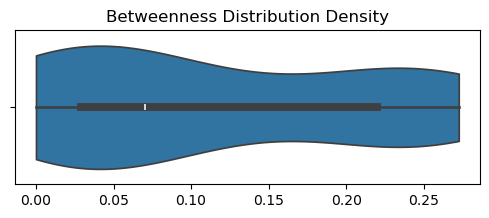

In [51]:
# Plot the distribution of betweenness density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=betweenness_s, orient='h', cut=0)
plt.title('Betweenness Distribution Density')
plt.show()

[10.0, 282.5840336134454, 38.886554621848745, 255.2731092436975, 131.4810924369748, 60.75280112044818, 78.52240896358543, 149.25070028011203, 258.84453781512605, 40.51470588235294, 265.5847338935574, 80.09803921568626, 227.9621848739496, 80.71078431372548, 10.0, 230.58823529411765, 27.769607843137255, 10.0]
18
18


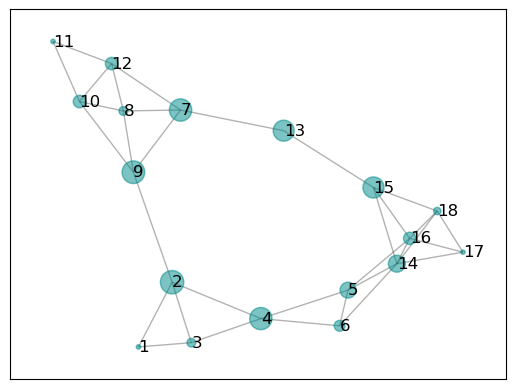

In [52]:

# Visualize the graph with betweenness values
pos = nx.spring_layout(G)

node_size = [b[1]*1000+10 for b in lb]
print(node_size)
print(len(node_size))
print(len(G.nodes))

for core_number, community in communities.items():
    nx.draw_networkx_nodes(G, pos, node_color='darkCyan', node_size=node_size,
                           alpha=0.3)


nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, horizontalalignment='left')
plt.show()

### Eigenvector

In [53]:
le = list(nx.eigenvector_centrality(G).items())
pprint.pprint(sorted(le, key=lambda tup: tup[1], reverse=True))


[(14, 0.48619196950476534),
 (16, 0.44090534800203046),
 (18, 0.3790662684581689),
 (15, 0.3363319771805264),
 (5, 0.31915690599069624),
 (17, 0.3138993924555399),
 (6, 0.23372817515401398),
 (4, 0.16721427061174451),
 (13, 0.09334325023977787),
 (2, 0.07616325000648168),
 (3, 0.06674304318120444),
 (7, 0.052074932985247874),
 (9, 0.04861641952704002),
 (8, 0.04049140510628165),
 (1, 0.03434392893262418),
 (12, 0.03422809880921652),
 (10, 0.033558002708432795),
 (11, 0.016291819845398858)]


In [54]:
### Plot eigenvector density distribution 
eigenvector_s = pd.Series([e[1] for e in le])
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

count    18.00000000000000000000
mean      0.17624158103884396409
std       0.16104443888579958455
min       0.01629181984539885761
25%       0.04252265871147124093
50%       0.08475325012312977246
75%       0.31784252760690712147
max       0.48619196950476534225
dtype: object


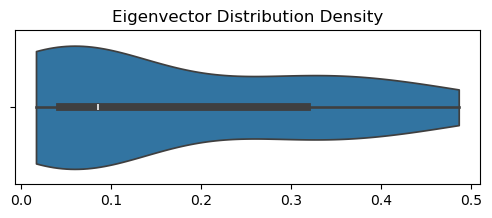

In [55]:
# Plot the distribution of eigenvector density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=eigenvector_s, orient='h', cut=0)
plt.title('Eigenvector Distribution Density')
plt.show()

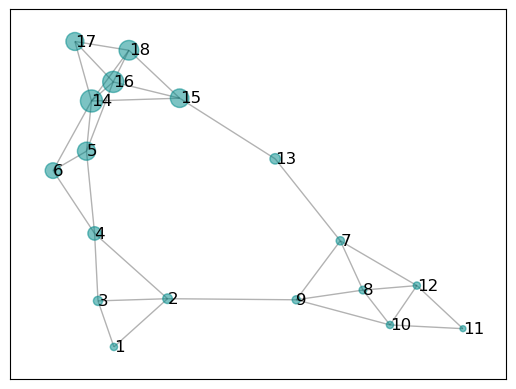

In [57]:

# Visualize the graph with eigenvector centrality
pos = nx.spring_layout(G)

node_size = [e[1]*500+10 for e in le]

for core_number, community in communities.items():
    nx.draw_networkx_nodes(G, pos, node_color='darkCyan', node_size=node_size,
                           alpha=0.3)


nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, horizontalalignment='left')
plt.show()